# Airbnb Model Optimization Lab

This notebook is a sandbox for feature-set experiments, model tuning, and residual analysis.


## 1. Imports and Experiment Settings

Use this notebook to compare feature sets first, then tune the best-performing model on the strongest feature set.


In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

DATA_PATH = Path('AB_NYC_2019.csv')
TEST_SIZE = 0.2
RANDOM_STATE = 42
CV_FOLDS = 3
TOP_K_FEATURE_SETS_TO_TUNE = 2

print(f'Using dataset at: {DATA_PATH.resolve()}')


Using dataset at: /Users/bowen/Desktop/644-project/AB_NYC_2019.csv


## Current Focus

This notebook has been trimmed to keep only the experiments that still support the current modeling direction: final baseline evaluation, grouped error analysis, room-type segmentation, and the split between typical listings (`price < 500`) and high-price listings (`price >= 500`).


## 2. Load and Clean Data


In [11]:
raw_df = pd.read_csv(DATA_PATH)
print(f'Original shape: {raw_df.shape}')

clean_df = raw_df.copy()
clean_df['reviews_per_month'] = clean_df['reviews_per_month'].fillna(0)
clean_df = clean_df.dropna(subset=['neighbourhood_group', 'room_type'])
clean_df = clean_df[clean_df['price'] > 0]
lower = clean_df['price'].quantile(0.01)
upper = clean_df['price'].quantile(0.99)
clean_df = clean_df[(clean_df['price'] >= lower) & (clean_df['price'] <= upper)].copy()

clean_df['last_review'] = pd.to_datetime(clean_df['last_review'])
latest_review_date = clean_df['last_review'].max()
clean_df['days_since_last_review'] = (
    latest_review_date - clean_df['last_review']
).dt.days
clean_df['days_since_last_review'] = clean_df['days_since_last_review'].fillna(-1)
clean_df['is_multi_listing_host'] = (
    clean_df['calculated_host_listings_count'] > 1
).astype(int)
clean_df['reviews_per_month_log'] = np.log1p(clean_df['reviews_per_month'])
clean_df['minimum_nights_log'] = np.log1p(clean_df['minimum_nights'])
clean_df['host_listings_log'] = np.log1p(clean_df['calculated_host_listings_count'])
clean_df['number_of_reviews_log'] = np.log1p(clean_df['number_of_reviews'])

print(f'Cleaned shape: {clean_df.shape}')
clean_df.head()


Original shape: (48895, 16)
Cleaned shape: (48017, 22)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,is_multi_listing_host,reviews_per_month_log,minimum_nights_log,host_listings_log,number_of_reviews_log
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,262.0,1,0.190620,0.693147,1.945910,2.302585
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,48.0,1,0.322083,0.693147,1.098612,3.828641
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,-1.0,0,0.000000,1.386294,0.693147,0.000000
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,3.0,0,1.729884,0.693147,0.693147,5.602119
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,231.0,0,0.095310,2.397895,0.693147,2.302585


## 3. Define Feature Sets

Start with a few interpretable groups so it is easy to see whether extra columns actually help.


In [12]:
feature_sets = {
    'location_core': [
        'latitude',
        'longitude',
        'neighbourhood_group',
        'room_type',
    ],
    'location_plus_neighbourhood': [
        'latitude',
        'longitude',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
    'current_workflow': [
        'latitude',
        'longitude',
        'minimum_nights',
        'number_of_reviews',
        'reviews_per_month',
        'calculated_host_listings_count',
        'availability_365',
        'neighbourhood_group',
        'room_type',
    ],
    'workflow_plus_neighbourhood': [
        'latitude',
        'longitude',
        'minimum_nights',
        'number_of_reviews',
        'reviews_per_month',
        'calculated_host_listings_count',
        'availability_365',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
    'workflow_minus_reviews': [
        'latitude',
        'longitude',
        'minimum_nights',
        'calculated_host_listings_count',
        'availability_365',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
    'engineered_full': [
        'latitude',
        'longitude',
        'minimum_nights',
        'minimum_nights_log',
        'number_of_reviews',
        'number_of_reviews_log',
        'reviews_per_month',
        'reviews_per_month_log',
        'calculated_host_listings_count',
        'host_listings_log',
        'availability_365',
        'days_since_last_review',
        'is_multi_listing_host',
        'neighbourhood_group',
        'neighbourhood',
        'room_type',
    ],
}

pd.DataFrame(
    {
        'Feature Set': feature_sets.keys(),
        'Feature Count': [len(cols) for cols in feature_sets.values()],
    }
)


,Feature Set,Feature Count
0,location_core,4
1,location_plus_neighbourhood,5
2,current_workflow,9
3,workflow_plus_neighbourhood,10
4,workflow_minus_reviews,8
5,engineered_full,16


## 4. Utilities for Preprocessing and Evaluation


In [13]:
def split_feature_types(feature_columns):
    numeric_columns = [
        col for col in feature_columns
        if pd.api.types.is_numeric_dtype(clean_df[col])
    ]
    categorical_columns = [
        col for col in feature_columns
        if col not in numeric_columns
    ]
    return numeric_columns, categorical_columns


def build_preprocessor(feature_columns):
    numeric_columns, categorical_columns = split_feature_types(feature_columns)

    transformers = []
    if numeric_columns:
        transformers.append(
            (
                'num',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]),
                numeric_columns,
            )
        )
    if categorical_columns:
        transformers.append(
            (
                'cat',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(handle_unknown='ignore')),
                ]),
                categorical_columns,
            )
        )

    return ColumnTransformer(transformers=transformers)



def build_model_candidates(preprocessor):
    return {
        'Random Forest Baseline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        'Random Forest Stronger': Pipeline([
            ('preprocessor', preprocessor),
            ('model', RandomForestRegressor(
                n_estimators=300,
                max_depth=16,
                min_samples_leaf=1,
                max_features='sqrt',
                random_state=RANDOM_STATE,
                n_jobs=1,
            )),
        ]),
        'Gradient Boosting Baseline': Pipeline([
            ('preprocessor', preprocessor),
            ('model', GradientBoostingRegressor(random_state=RANDOM_STATE)),
        ]),
        'Gradient Boosting Tuned': Pipeline([
            ('preprocessor', preprocessor),
            ('model', GradientBoostingRegressor(
                n_estimators=500,
                learning_rate=0.1,
                max_depth=4,
                subsample=0.8,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
            )),
        ]),
        'Gradient Boosting Log Target': Pipeline([
            ('preprocessor', preprocessor),
            ('model', TransformedTargetRegressor(
                regressor=GradientBoostingRegressor(
                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=3,
                    subsample=0.8,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                ),
                func=np.log1p,
                inverse_func=np.expm1,
            )),
        ]),
    }


def evaluate_pipeline(name, pipeline, X_train, X_test, y_train, y_test):
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        n_jobs=1,
    )
    cv_mse = (-cv_scores).mean()

    pipeline.fit(X_train, y_train)
    train_pred = pipeline.predict(X_train)
    test_pred = pipeline.predict(X_test)

    return {
        'Model': name,
        'Train MSE': mean_squared_error(y_train, train_pred),
        'Test MSE': mean_squared_error(y_test, test_pred),
        'Test RMSE': mean_squared_error(y_test, test_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'Test R2': r2_score(y_test, test_pred),
        f'CV MSE ({CV_FOLDS}-fold)': cv_mse,
        'fitted_model': pipeline,
        'test_predictions': test_pred,
    }
split_feature_types(['latitude', 'neighbourhood', 'room_type'])


(['latitude'], ['neighbourhood', 'room_type'])

## 8A. Final Random Forest Evaluation on Full Data

Lock in the current best random forest configuration and evaluate it on the full cleaned dataset with the original workflow feature set.


In [14]:
FINAL_FEATURE_SET_NAME = 'current_workflow'
FINAL_FEATURES = feature_sets[FINAL_FEATURE_SET_NAME]
FINAL_RF_PARAMS = {
    'n_estimators': 400,
    'max_depth': 16,
    'max_features': 'sqrt',
    'min_samples_leaf': 2,
    'min_samples_split': 5,
}

X_final = clean_df[FINAL_FEATURES]
y_final = clean_df['price']
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final,
    y_final,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

final_preprocessor = build_preprocessor(FINAL_FEATURES)
final_rf_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **FINAL_RF_PARAMS,
    )),
])

final_cv_scores = cross_val_score(
    final_rf_pipeline,
    X_train_final,
    y_train_final,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)
final_cv_mse = (-final_cv_scores).mean()

final_rf_pipeline.fit(X_train_final, y_train_final)
final_train_pred = final_rf_pipeline.predict(X_train_final)
final_test_pred = final_rf_pipeline.predict(X_test_final)
final_residuals = y_test_final - final_test_pred

final_results = pd.Series({
    'Feature Set': FINAL_FEATURE_SET_NAME,
    'Train MSE': mean_squared_error(y_train_final, final_train_pred),
    'Test MSE': mean_squared_error(y_test_final, final_test_pred),
    'Test RMSE': mean_squared_error(y_test_final, final_test_pred) ** 0.5,
    'Test MAE': mean_absolute_error(y_test_final, final_test_pred),
    'Test R2': r2_score(y_test_final, final_test_pred),
    f'CV MSE ({CV_FOLDS}-fold)': final_cv_mse,
})

print('Final Random Forest parameters:')
print(FINAL_RF_PARAMS)
print()
final_results


Final Random Forest parameters:
{'n_estimators': 400, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5}



Feature Set        current_workflow
Train MSE               3388.802262
Test MSE                5499.529699
Test RMSE                 74.158814
Test MAE                  44.842373
Test R2                    0.491705
CV MSE (3-fold)         5389.928008
dtype: object

## 8B. Grouped Error Analysis

Check where the model struggles most by price bucket, room type, and borough before deciding what to engineer next.


In [15]:
error_analysis_df = X_test_final.copy()
error_analysis_df['actual_price'] = y_test_final.values
error_analysis_df['predicted_price'] = final_test_pred
error_analysis_df['absolute_error'] = (
    error_analysis_df['actual_price'] - error_analysis_df['predicted_price']
).abs()
error_analysis_df['squared_error'] = (
    error_analysis_df['actual_price'] - error_analysis_df['predicted_price']
) ** 2

price_bins = [0, 100, 200, 300, 500, np.inf]
price_labels = ['<100', '100-200', '200-300', '300-500', '500+']
error_analysis_df['price_bucket'] = pd.cut(
    error_analysis_df['actual_price'],
    bins=price_bins,
    labels=price_labels,
    right=False,
)

def summarize_group_errors(df, group_col):
    return (
        df.groupby(group_col, observed=False)
        .agg(
            sample_size=('actual_price', 'size'),
            mean_actual_price=('actual_price', 'mean'),
            mean_predicted_price=('predicted_price', 'mean'),
            mae=('absolute_error', 'mean'),
            rmse=('squared_error', lambda s: np.sqrt(s.mean())),
        )
        .sort_values('mae', ascending=False)
    )

price_bucket_error_df = summarize_group_errors(error_analysis_df, 'price_bucket')
room_type_error_df = summarize_group_errors(error_analysis_df, 'room_type')
borough_error_df = summarize_group_errors(error_analysis_df, 'neighbourhood_group')

print('Error by price bucket')
display(price_bucket_error_df)
print('Error by room type')
display(room_type_error_df)
print('Error by borough')
display(borough_error_df)


Error by price bucket


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
price_bucket,,,,,
500+,143,610.076923,260.723030,349.353893,369.361148
300-500,581,365.784854,227.293505,140.257398,158.574612
200-300,1156,235.429931,207.532223,50.225870,63.236130
100-200,3398,140.031489,161.267086,39.511598,50.997756
<100,4326,65.756588,86.325851,24.710466,34.798519


Error by room type


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
room_type,,,,,
Entire home/apt,4999,188.414683,188.839209,62.476373,91.987261
Shared room,207,72.449275,77.427270,30.578515,51.956252
Private room,4398,85.340382,84.275741,25.469988,47.585822


Error by borough


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
neighbourhood_group,,,,,
Manhattan,4228,174.185194,173.008999,55.697531,86.207405
Staten Island,83,91.180723,90.237518,39.027764,78.462978
Brooklyn,3973,116.698465,118.056620,37.989560,64.093110
Bronx,229,88.646288,88.762206,31.623972,58.749778
Queens,1091,95.548121,93.805779,30.947084,58.815107


## 8C. Final Model Plots


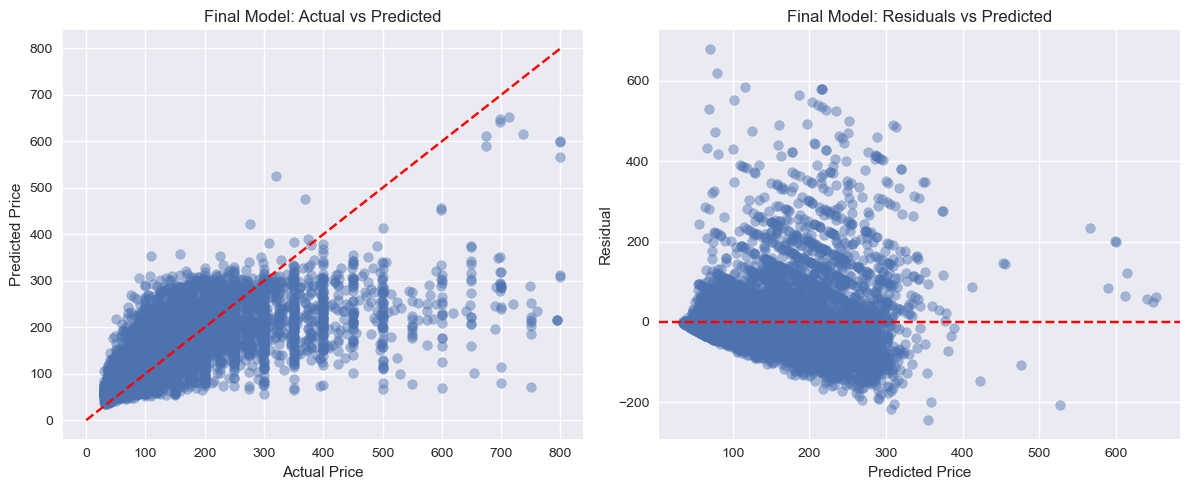

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_final, final_test_pred, alpha=0.45)
max_val = max(y_test_final.max(), final_test_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_title('Final Model: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(final_test_pred, final_residuals, alpha=0.45)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Final Model: Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()


## 8E. High-Price and Entire-Home Error Analysis

Inspect the samples that drive most of the error so the next feature-engineering step can be more targeted.


In [17]:
high_price_threshold = 300
focused_error_df = error_analysis_df.copy()
focused_error_df['residual'] = focused_error_df['actual_price'] - focused_error_df['predicted_price']
focused_error_df['is_high_price'] = focused_error_df['actual_price'] >= high_price_threshold
focused_error_df['is_entire_home'] = focused_error_df['room_type'] == 'Entire home/apt'

# Bring back neighbourhood labels from the original cleaned frame for drill-down analysis.
focused_error_df = focused_error_df.join(clean_df[['neighbourhood']], how='left')

high_price_df = focused_error_df[focused_error_df['is_high_price']].copy()
entire_home_df = focused_error_df[focused_error_df['is_entire_home']].copy()
high_price_entire_home_df = focused_error_df[
    focused_error_df['is_high_price'] & focused_error_df['is_entire_home']
].copy()


def summarize_slice(name, df):
    if df.empty:
        return {
            'Slice': name,
            'sample_size': 0,
            'mean_actual_price': np.nan,
            'mean_predicted_price': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'mean_residual': np.nan,
        }

    return {
        'Slice': name,
        'sample_size': len(df),
        'mean_actual_price': df['actual_price'].mean(),
        'mean_predicted_price': df['predicted_price'].mean(),
        'mae': df['absolute_error'].mean(),
        'rmse': np.sqrt(df['squared_error'].mean()),
        'mean_residual': df['residual'].mean(),
    }


focused_slice_summary_df = pd.DataFrame([
    summarize_slice('High price (300+)', high_price_df),
    summarize_slice('Entire home/apt', entire_home_df),
    summarize_slice('High price + Entire home/apt', high_price_entire_home_df),
])

high_price_borough_df = summarize_group_errors(high_price_df, 'neighbourhood_group')
high_price_room_type_df = summarize_group_errors(high_price_df, 'room_type')
high_price_neighbourhood_df = (
    high_price_df.groupby('neighbourhood', observed=False)
    .agg(
        sample_size=('actual_price', 'size'),
        mean_actual_price=('actual_price', 'mean'),
        mean_predicted_price=('predicted_price', 'mean'),
        mae=('absolute_error', 'mean'),
        rmse=('squared_error', lambda s: np.sqrt(s.mean())),
    )
    .sort_values(['sample_size', 'mae'], ascending=[False, False])
    .head(15)
)

print('Focused slice summary')
display(focused_slice_summary_df)
print('High-price error by borough')
display(high_price_borough_df)
print('High-price error by room type')
display(high_price_room_type_df)
print('Top high-price neighbourhoods in the test split')
display(high_price_neighbourhood_df)



Focused slice summary


,Slice,sample_size,mean_actual_price,mean_predicted_price,mae,rmse,mean_residual
0,High price (300+),724,414.035912,233.896298,181.556844,217.084293,180.139614
1,Entire home/apt,4999,188.414683,188.839209,62.476373,91.987261,-0.424526
2,High price + Entire home/apt,626,413.351438,238.109537,176.389682,210.839851,175.241901


High-price error by borough


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
neighbourhood_group,,,,,
Staten Island,1,700.000000,115.285289,584.714711,584.714711
Bronx,5,404.800000,110.861285,293.938715,317.087213
Queens,27,429.296296,150.658079,278.638217,303.132073
Brooklyn,175,402.885714,193.773434,209.503769,238.107946
Manhattan,516,416.554264,253.281413,165.128595,201.119041


High-price error by room type


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
room_type,,,,,
Shared room,5,390.000000,149.861547,240.138453,240.585250
Private room,93,419.935484,210.054212,213.188407,254.035511
Entire home/apt,626,413.351438,238.109537,176.389682,210.839851


Top high-price neighbourhoods in the test split


,sample_size,mean_actual_price,mean_predicted_price,mae,rmse
neighbourhood,,,,,
Midtown,92,450.173913,310.366935,143.150060,187.481929
Hell's Kitchen,59,401.084746,247.660329,160.604869,185.724142
Chelsea,43,399.976744,241.872771,159.994220,199.168985
Williamsburg,42,403.095238,224.315367,180.411073,216.810258
East Village,40,408.200000,226.312282,181.887718,218.594890
Upper West Side,40,385.850000,233.458398,152.391602,177.640989
Upper East Side,29,429.172414,215.088798,214.083616,250.601649
Murray Hill,24,410.041667,250.329041,159.712626,195.925602
Bedford-Stuyvesant,22,420.954545,164.069734,256.884812,289.523872


## 8F. Segmented Modeling by Room Type

Train separate models by `room_type` to test whether a split between entire homes and room rentals reduces the average error.


In [18]:
SEGMENTED_FEATURES = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'neighbourhood_group',
]

segmented_results = []
segmented_predictions = []
segmented_models = {}
segment_cv_col = f'Segment CV MSE ({CV_FOLDS}-fold)'

for room_type_name in sorted(clean_df['room_type'].unique()):
    segment_df = clean_df[clean_df['room_type'] == room_type_name].copy()
    X_segment = segment_df[SEGMENTED_FEATURES]
    y_segment = segment_df['price']

    X_train_segment, X_test_segment, y_train_segment, y_test_segment = train_test_split(
        X_segment,
        y_segment,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    segment_preprocessor = build_preprocessor(SEGMENTED_FEATURES)
    segment_pipeline = Pipeline([
        ('preprocessor', segment_preprocessor),
        ('model', RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            **FINAL_RF_PARAMS,
        )),
    ])

    segment_cv_scores = cross_val_score(
        segment_pipeline,
        X_train_segment,
        y_train_segment,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        n_jobs=1,
    )
    segment_cv_mse = (-segment_cv_scores).mean()

    segment_pipeline.fit(X_train_segment, y_train_segment)
    segment_pred = segment_pipeline.predict(X_test_segment)

    segmented_results.append({
        'room_type': room_type_name,
        'sample_size': len(segment_df),
        'Test MSE': mean_squared_error(y_test_segment, segment_pred),
        'Test RMSE': mean_squared_error(y_test_segment, segment_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test_segment, segment_pred),
        'Test R2': r2_score(y_test_segment, segment_pred),
        segment_cv_col: segment_cv_mse,
    })

    segmented_predictions.append(pd.DataFrame({
        'room_type': room_type_name,
        'actual_price': y_test_segment.values,
        'predicted_price': segment_pred,
    }))
    segmented_models[room_type_name] = segment_pipeline

segmented_results_df = pd.DataFrame(segmented_results).sort_values('Test MSE').reset_index(drop=True)
segmented_predictions_df = pd.concat(segmented_predictions, ignore_index=True)
segmented_overall_metrics = pd.Series({
    'Test MSE': mean_squared_error(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']),
    'Test RMSE': mean_squared_error(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']) ** 0.5,
    'Test MAE': mean_absolute_error(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']),
    'Test R2': r2_score(segmented_predictions_df['actual_price'], segmented_predictions_df['predicted_price']),
})

print('Per-room-type segmented results')
display(segmented_results_df)
print('Combined segmented-model performance across all room types')
display(segmented_overall_metrics)
print('Current global model baseline for comparison')
display(final_results[['Test MSE', 'Test RMSE', 'Test MAE', 'Test R2']])


Per-room-type segmented results


,room_type,sample_size,Test MSE,Test RMSE,Test MAE,Test R2,Segment CV MSE (3-fold)
0,Private room,22042,2160.992759,46.486479,25.202982,0.338626,2061.965739
1,Shared room,976,4907.350656,70.052485,31.652954,0.134036,2779.433164
2,Entire home/apt,24999,8135.105249,90.194818,61.759646,0.303344,8483.237843


Combined segmented-model performance across all room types


Test MSE     5326.932228
Test RMSE      72.985836
Test MAE       44.364618
Test R2         0.489540
dtype: float64

Current global model baseline for comparison


Test MSE     5499.529699
Test RMSE      74.158814
Test MAE       44.842373
Test R2         0.491705
dtype: object

## 8H. Typical Listings Model (price < 500)

Treat sub-$500 listings as the main prediction task and compare a segmented-by-room-type strategy against a single global model.


In [19]:
TYPICAL_PRICE_THRESHOLD = 500
typical_df = clean_df[clean_df['price'] < TYPICAL_PRICE_THRESHOLD].copy()

X_typical = typical_df[FINAL_FEATURES]
y_typical = typical_df['price']
X_train_typical, X_test_typical, y_train_typical, y_test_typical = train_test_split(
    X_typical,
    y_typical,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

typical_global_preprocessor = build_preprocessor(FINAL_FEATURES)
typical_global_pipeline = Pipeline([
    ('preprocessor', typical_global_preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **FINAL_RF_PARAMS,
    )),
])

typical_global_cv_scores = cross_val_score(
    typical_global_pipeline,
    X_train_typical,
    y_train_typical,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)
typical_global_cv_mse = (-typical_global_cv_scores).mean()
typical_global_pipeline.fit(X_train_typical, y_train_typical)
typical_global_pred = typical_global_pipeline.predict(X_test_typical)

typical_segmented_predictions = []
for room_type_name in sorted(typical_df['room_type'].unique()):
    room_df = typical_df[typical_df['room_type'] == room_type_name].copy()
    X_room = room_df[SEGMENTED_FEATURES]
    y_room = room_df['price']

    X_train_room, X_test_room, y_train_room, y_test_room = train_test_split(
        X_room,
        y_room,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    room_preprocessor = build_preprocessor(SEGMENTED_FEATURES)
    room_pipeline = Pipeline([
        ('preprocessor', room_preprocessor),
        ('model', RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            **FINAL_RF_PARAMS,
        )),
    ])
    room_pipeline.fit(X_train_room, y_train_room)
    room_pred = room_pipeline.predict(X_test_room)

    typical_segmented_predictions.append(pd.DataFrame({
        'room_type': room_type_name,
        'actual_price': y_test_room.values,
        'predicted_price': room_pred,
    }))

typical_segmented_predictions_df = pd.concat(typical_segmented_predictions, ignore_index=True)

typical_results_df = pd.DataFrame([
    {
        'Model': 'Typical global model (<500)',
        'Sample Size': len(typical_df),
        'Test MSE': mean_squared_error(y_test_typical, typical_global_pred),
        'Test RMSE': mean_squared_error(y_test_typical, typical_global_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test_typical, typical_global_pred),
        'Test R2': r2_score(y_test_typical, typical_global_pred),
        f'CV MSE ({CV_FOLDS}-fold)': typical_global_cv_mse,
    },
    {
        'Model': 'Typical segmented model by room_type (<500)',
        'Sample Size': len(typical_df),
        'Test MSE': mean_squared_error(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']),
        'Test RMSE': mean_squared_error(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']) ** 0.5,
        'Test MAE': mean_absolute_error(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']),
        'Test R2': r2_score(typical_segmented_predictions_df['actual_price'], typical_segmented_predictions_df['predicted_price']),
        f'CV MSE ({CV_FOLDS}-fold)': np.nan,
    },
])

print(f'Typical-listings sample size (<{TYPICAL_PRICE_THRESHOLD}): {len(typical_df)}')
typical_results_df


Typical-listings sample size (<500): 47256


,Model,Sample Size,Test MSE,Test RMSE,Test MAE,Test R2,CV MSE (3-fold)
0,Typical global model (<500),47256,3308.983214,57.523762,38.425994,0.534302,3344.583726
1,Typical segmented model by room_type (<500),47256,3198.021036,56.551048,38.319598,0.555099,NaN


## 8I. High-Price Listings Analysis (price >= 500)

Describe the data scarcity and error profile for high-price listings before deciding whether to model them separately or treat them as an analysis-only slice.


In [20]:
high_price_only_df = clean_df[clean_df['price'] >= TYPICAL_PRICE_THRESHOLD].copy()
print(f'High-price sample size (>={TYPICAL_PRICE_THRESHOLD}): {len(high_price_only_df)}')

high_price_summary = pd.Series({
    'sample_size': len(high_price_only_df),
    'mean_price': high_price_only_df['price'].mean(),
    'median_price': high_price_only_df['price'].median(),
    'std_price': high_price_only_df['price'].std(),
    'min_price': high_price_only_df['price'].min(),
    'max_price': high_price_only_df['price'].max(),
})

high_price_room_distribution = high_price_only_df['room_type'].value_counts().to_frame('count')
high_price_borough_distribution = high_price_only_df['neighbourhood_group'].value_counts().to_frame('count')
high_price_neighbourhood_distribution = high_price_only_df['neighbourhood'].value_counts().head(15).to_frame('count')

display(high_price_summary)
print('High-price listings by room type')
display(high_price_room_distribution)
print('High-price listings by borough')
display(high_price_borough_distribution)
print('Top high-price neighbourhoods overall')
display(high_price_neighbourhood_distribution)


High-price sample size (>=500): 761


sample_size     761.000000
mean_price      606.629435
median_price    600.000000
std_price        91.878635
min_price       500.000000
max_price       799.000000
dtype: float64

High-price listings by room type


,count
room_type,
Entire home/apt,665
Private room,92
Shared room,4


High-price listings by borough


,count
neighbourhood_group,
Manhattan,557
Brooklyn,176
Queens,20
Bronx,6
Staten Island,2


Top high-price neighbourhoods overall


,count
neighbourhood,
Midtown,142
Williamsburg,56
Hell's Kitchen,50
Upper West Side,40
Chelsea,37
West Village,30
East Village,30
Upper East Side,30
SoHo,28


## 8J. Split-Task Comparison

Compare the current all-listings model against the typical-listings model so it is clear how much the high-price tail affects the overall error.


## 8L. High-Price Listings Model (price >= 500)

Train a dedicated random forest model for the high-price segment so the split-task strategy includes a real predictive model on both sides of the threshold.


In [21]:
HIGH_PRICE_FEATURES = FINAL_FEATURES
X_high = high_price_only_df[HIGH_PRICE_FEATURES]
y_high = high_price_only_df['price']

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(
    X_high,
    y_high,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

high_preprocessor = build_preprocessor(HIGH_PRICE_FEATURES)
high_price_pipeline = Pipeline([
    ('preprocessor', high_preprocessor),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=1,
        **FINAL_RF_PARAMS,
    )),
])

high_cv_scores = cross_val_score(
    high_price_pipeline,
    X_train_high,
    y_train_high,
    cv=CV_FOLDS,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)
high_cv_mse = (-high_cv_scores).mean()

high_price_pipeline.fit(X_train_high, y_train_high)
high_test_pred = high_price_pipeline.predict(X_test_high)
high_residuals = y_test_high - high_test_pred

high_price_results = pd.Series({
    'Feature Set': 'current_workflow',
    'Sample Size': len(high_price_only_df),
    'Train MSE': mean_squared_error(y_train_high, high_price_pipeline.predict(X_train_high)),
    'Test MSE': mean_squared_error(y_test_high, high_test_pred),
    'Test RMSE': mean_squared_error(y_test_high, high_test_pred) ** 0.5,
    'Test MAE': mean_absolute_error(y_test_high, high_test_pred),
    'Test R2': r2_score(y_test_high, high_test_pred),
    f'CV MSE ({CV_FOLDS}-fold)': high_cv_mse,
})

print('High-price model parameters:')
print(FINAL_RF_PARAMS)
print()
high_price_results


High-price model parameters:
{'n_estimators': 400, 'max_depth': 16, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5}



Feature Set        current_workflow
Sample Size                     761
Train MSE               3323.858523
Test MSE                6786.837427
Test RMSE                 82.382264
Test MAE                  66.416002
Test R2                    0.132731
CV MSE (3-fold)         7779.865856
dtype: object

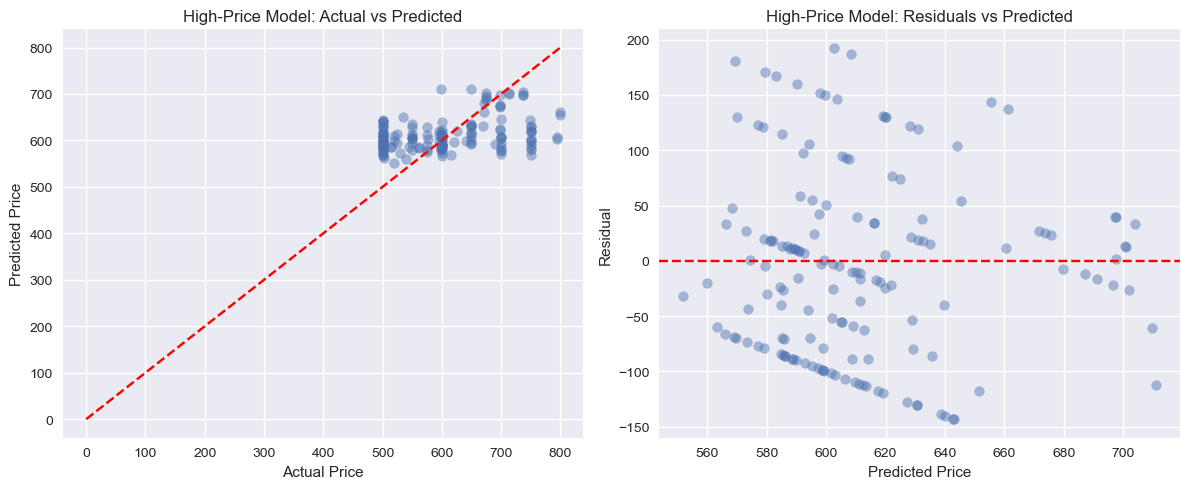

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test_high, high_test_pred, alpha=0.45)
max_val = max(y_test_high.max(), high_test_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_title('High-Price Model: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

axes[1].scatter(high_test_pred, high_residuals, alpha=0.45)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('High-Price Model: Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()


## 8M. Two-Part Prediction Summary

Summarize the final two-part modeling strategy: a dedicated model for typical listings under `$500` and a separate model for high-price listings at or above `$500`.


In [23]:
two_part_summary_df = pd.DataFrame([
    {
        'Price Segment': '<500',
        'Model': 'Segmented random forest by room_type',
        'Sample Size': 47256,
        'Test MSE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test MSE'].iloc[0],
        'Test RMSE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test RMSE'].iloc[0],
        'Test MAE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test MAE'].iloc[0],
        'Test R2': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test R2'].iloc[0],
    },
    {
        'Price Segment': '>=500',
        'Model': 'Global random forest',
        'Sample Size': len(high_price_only_df),
        'Test MSE': high_price_results['Test MSE'],
        'Test RMSE': high_price_results['Test RMSE'],
        'Test MAE': high_price_results['Test MAE'],
        'Test R2': high_price_results['Test R2'],
    },
])

two_part_summary_df


,Price Segment,Model,Sample Size,Test MSE,Test RMSE,Test MAE,Test R2
0,<500,Segmented random forest by room_type,47256,3198.021036,56.551048,38.319598,0.555099
1,>=500,Global random forest,761,6786.837427,82.382264,66.416002,0.132731


## 8K. Typical Segmented Model with Spatial Bucket Features

Test whether a coarse spatial bucket built from latitude and longitude can improve the `<500` segmented model without the sparsity issues of raw `neighbourhood` labels.


In [24]:
SPATIAL_BUCKET_DECIMALS = 2
clean_df['lat_bucket'] = clean_df['latitude'].round(SPATIAL_BUCKET_DECIMALS)
clean_df['lon_bucket'] = clean_df['longitude'].round(SPATIAL_BUCKET_DECIMALS)
clean_df['spatial_bucket'] = (
    clean_df['lat_bucket'].astype(str) + '_' + clean_df['lon_bucket'].astype(str)
)

typical_spatial_df = clean_df[clean_df['price'] < TYPICAL_PRICE_THRESHOLD].copy()
SPATIAL_SEGMENTED_FEATURES = [
    'latitude',
    'longitude',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'availability_365',
    'neighbourhood_group',
    'spatial_bucket',
]

spatial_segmented_predictions = []
spatial_segmented_results = []

for room_type_name in sorted(typical_spatial_df['room_type'].unique()):
    room_df = typical_spatial_df[typical_spatial_df['room_type'] == room_type_name].copy()
    X_room = room_df[SPATIAL_SEGMENTED_FEATURES]
    y_room = room_df['price']

    X_train_room, X_test_room, y_train_room, y_test_room = train_test_split(
        X_room,
        y_room,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    room_preprocessor = build_preprocessor(SPATIAL_SEGMENTED_FEATURES)
    room_pipeline = Pipeline([
        ('preprocessor', room_preprocessor),
        ('model', RandomForestRegressor(
            random_state=RANDOM_STATE,
            n_jobs=1,
            **FINAL_RF_PARAMS,
        )),
    ])

    room_cv_scores = cross_val_score(
        room_pipeline,
        X_train_room,
        y_train_room,
        cv=CV_FOLDS,
        scoring='neg_mean_squared_error',
        n_jobs=1,
    )
    room_cv_mse = (-room_cv_scores).mean()

    room_pipeline.fit(X_train_room, y_train_room)
    room_pred = room_pipeline.predict(X_test_room)

    spatial_segmented_results.append({
        'room_type': room_type_name,
        'sample_size': len(room_df),
        'Test MSE': mean_squared_error(y_test_room, room_pred),
        'Test RMSE': mean_squared_error(y_test_room, room_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test_room, room_pred),
        'Test R2': r2_score(y_test_room, room_pred),
        f'CV MSE ({CV_FOLDS}-fold)': room_cv_mse,
    })

    spatial_segmented_predictions.append(pd.DataFrame({
        'room_type': room_type_name,
        'actual_price': y_test_room.values,
        'predicted_price': room_pred,
    }))

spatial_segmented_results_df = pd.DataFrame(spatial_segmented_results).sort_values('Test MSE').reset_index(drop=True)
spatial_segmented_predictions_df = pd.concat(spatial_segmented_predictions, ignore_index=True)
spatial_segmented_overall_metrics = pd.Series({
    'Test MSE': mean_squared_error(spatial_segmented_predictions_df['actual_price'], spatial_segmented_predictions_df['predicted_price']),
    'Test RMSE': mean_squared_error(spatial_segmented_predictions_df['actual_price'], spatial_segmented_predictions_df['predicted_price']) ** 0.5,
    'Test MAE': mean_absolute_error(spatial_segmented_predictions_df['actual_price'], spatial_segmented_predictions_df['predicted_price']),
    'Test R2': r2_score(spatial_segmented_predictions_df['actual_price'], spatial_segmented_predictions_df['predicted_price']),
})

spatial_comparison_df = pd.DataFrame([
    {
        'Model': 'Typical segmented baseline (<500)',
        'Feature Design': 'Original segmented features',
        'Test MSE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test MSE'].iloc[0],
        'Test RMSE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test RMSE'].iloc[0],
        'Test MAE': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test MAE'].iloc[0],
        'Test R2': typical_results_df.loc[typical_results_df['Model'] == 'Typical segmented model by room_type (<500)', 'Test R2'].iloc[0],
    },
    {
        'Model': 'Typical segmented + spatial bucket (<500)',
        'Feature Design': f'Added spatial_bucket with round({SPATIAL_BUCKET_DECIMALS})',
        'Test MSE': spatial_segmented_overall_metrics['Test MSE'],
        'Test RMSE': spatial_segmented_overall_metrics['Test RMSE'],
        'Test MAE': spatial_segmented_overall_metrics['Test MAE'],
        'Test R2': spatial_segmented_overall_metrics['Test R2'],
    },
])

print('Per-room-type results with spatial buckets')
display(spatial_segmented_results_df)
print('Overall comparison against the current best <500 segmented model')
display(spatial_comparison_df)


Per-room-type results with spatial buckets


,room_type,sample_size,Test MSE,Test RMSE,Test MAE,Test R2,CV MSE (3-fold)
0,Private room,21950,1483.581908,38.517294,25.209701,0.298948,1705.642705
1,Shared room,972,2385.166298,48.838164,26.962817,0.229720,2390.402761
2,Entire home/apt,24334,5692.598903,75.449313,57.038765,0.215359,5697.175069


Overall comparison against the current best <500 segmented model


,Model,Feature Design,Test MSE,Test RMSE,Test MAE,Test R2
0,Typical segmented baseline (<500),Original segmented features,3198.021036,56.551048,38.319598,0.555099
1,Typical segmented + spatial bucket (<500),Added spatial_bucket with round(2),3669.478509,60.576221,41.635210,0.489511


In [ ]:
split_task_comparison_df = pd.DataFrame([
    {
        'Task': 'All cleaned listings',
        'Sample Size': len(clean_df),
        'Model': 'Global final random forest',
        'Test MSE': final_results['Test MSE'],
        'Test RMSE': final_results['Test RMSE'],
        'Test MAE': final_results['Test MAE'],
        'Test R2': final_results['Test R2'],
        f'CV MSE ({CV_FOLDS}-fold)': final_results[f'CV MSE ({CV_FOLDS}-fold)'],
    },
    typical_results_df.iloc[0].to_dict() | {'Task': 'Typical listings only (<500)'},
    typical_results_df.iloc[1].to_dict() | {'Task': 'Typical listings only (<500)'},
])

split_task_comparison_df


,Task,Sample Size,Model,Test MSE,Test RMSE,Test MAE,Test R2,CV MSE (3-fold)
0,All cleaned listings,48017,Global final random forest,5499.529699,74.158814,44.842373,0.491705,5389.928008
1,Typical listings only (<500),47256,Typical global model (<500),3308.983214,57.523762,38.425994,0.534302,3344.583726
2,Typical listings only (<500),47256,Typical segmented model by room_type (<500),3198.021036,56.551048,38.319598,0.555099,NaN
